In [2]:
import torch
import sys
print("Interpreter:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Interpreter: d:\maga25\VKRTimeSeries\.venv\Scripts\python.exe
CUDA available: True
GPU name: NVIDIA GeForce GTX 1660


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if device.type == 'cuda':
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")
    print(f"Всего видеопамяти: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Используемое устройство: cuda
Видеокарта: NVIDIA GeForce GTX 1660
Всего видеопамяти: 6.44 GB


In [4]:
# Standard
import random

import numpy as np
import pandas as pd
import torch

# Third Party
from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
)

# First Party
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index

d:\maga25\VKRTimeSeries\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

------------------------------------------------------------------------


Дообучение на датасете pems-bay

In [6]:
import h5py

file_path = 'data/pems-bay.h5' 

with h5py.File(file_path, 'r') as f:
    # Выводим все ключи верхнего уровня
    print("Ключи верхнего уровня:", list(f.keys()))
    
    # Рекурсивно обходим все группы/датасеты
    def print_structure(name, obj):
        print(name, type(obj))
    f.visititems(print_structure)

Ключи верхнего уровня: ['speed']
speed <class 'h5py._hl.group.Group'>
speed/axis0 <class 'h5py._hl.dataset.Dataset'>
speed/axis1 <class 'h5py._hl.dataset.Dataset'>
speed/block0_items <class 'h5py._hl.dataset.Dataset'>
speed/block0_values <class 'h5py._hl.dataset.Dataset'>


In [7]:
import h5py
import pandas as pd
import numpy as np

file_path = 'data/pems-bay.h5'

with h5py.File(file_path, 'r') as f:
    # Выведем структуру для понимания
    def print_structure(name, obj):
        print(f"{name} : {type(obj)}")
    f.visititems(print_structure)
    
    # Обычно данные лежат в группе 'speed'
    group = f['speed']
    data = group['block0_values'][:]          # (52116, 325)
    columns_raw = group['block0_items'][:]    # 325 названий сенсоров
    
    # Преобразуем названия столбцов в строки
    if columns_raw.dtype.type is np.bytes_:
        columns = [col.decode('utf-8') for col in columns_raw]
    else:
        columns = list(columns_raw)
    
    # Попробуем найти временные метки (если есть)
    index = None
    if 'axis0' in group:
        index_raw = group['axis0'][:]
        if len(index_raw) == data.shape[0]:
            if index_raw.dtype.type is np.bytes_:
                index = [idx.decode('utf-8') for idx in index_raw]
            else:
                index = index_raw
            print(f"Используем axis0 как индекс (длина {len(index)})")
        else:
            print(f"axis0 имеет длину {len(index_raw)}, но данных {data.shape[0]} — не используем")
    
    # Если индекс не найден, создаём без него
    if index is None:
        df = pd.DataFrame(data, columns=columns)
    else:
        df = pd.DataFrame(data, columns=columns, index=index)

print("Размер данных:", df.shape)
print("Первые 5 строк:")
print(df.head())

speed : <class 'h5py._hl.group.Group'>
speed/axis0 : <class 'h5py._hl.dataset.Dataset'>
speed/axis1 : <class 'h5py._hl.dataset.Dataset'>
speed/block0_items : <class 'h5py._hl.dataset.Dataset'>
speed/block0_values : <class 'h5py._hl.dataset.Dataset'>
axis0 имеет длину 325, но данных 52116 — не используем
Размер данных: (52116, 325)
Первые 5 строк:
   400001  400017  400030  400040  400045  400052  400057  400059  400065  \
0    71.4    67.8    70.5    67.4    68.8    66.6    66.8    68.0    66.8   
1    71.6    67.5    70.6    67.5    68.7    66.6    66.8    67.8    66.5   
2    71.6    67.6    70.2    67.4    68.7    66.1    66.8    67.8    66.2   
3    71.1    67.5    70.3    68.0    68.5    66.7    66.6    67.7    65.9   
4    71.7    67.8    70.2    68.1    68.4    66.9    66.1    67.7    66.1   

   400069  ...  409525  409526  409528  409529  413026  413845  413877  \
0    69.0  ...    68.8    67.9    68.8    68.0    69.2    68.9    70.4   
1    68.2  ...    68.4    67.3    68.4  

Дисперсия, объясняемая первыми 10 компонентами:
  PC1: 0.3673 (36.73%)
  PC2: 0.2508 (25.08%)
  PC3: 0.0252 (2.52%)
  PC4: 0.0190 (1.90%)
  PC5: 0.0170 (1.70%)
  PC6: 0.0139 (1.39%)
  PC7: 0.0108 (1.08%)
  PC8: 0.0097 (0.97%)
  PC9: 0.0092 (0.92%)
  PC10: 0.0080 (0.80%)

Накопленная дисперсия для первых 10 компонентов:
  PC1: 0.3673 (36.73%)
  PC2: 0.6181 (61.81%)
  PC3: 0.6433 (64.33%)
  PC4: 0.6624 (66.24%)
  PC5: 0.6794 (67.94%)
  PC6: 0.6933 (69.33%)
  PC7: 0.7041 (70.41%)
  PC8: 0.7138 (71.38%)
  PC9: 0.7230 (72.30%)
  PC10: 0.7310 (73.10%)

Для объяснения 95% дисперсии требуется 114 компонент(ы).


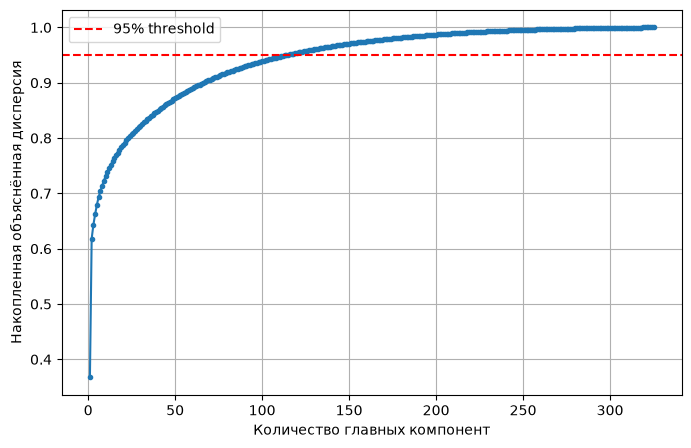

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Извлекаем числовые данные
data_matrix = df.select_dtypes(include=[np.number]).values

# Стандартизация
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_matrix)

# PCA
pca = PCA()
pca.fit(data_scaled)

# Вывод дисперсии
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

print("Дисперсия, объясняемая первыми 10 компонентами:")
for i, ev in enumerate(explained_variance_ratio[:10], 1):
    print(f"  PC{i}: {ev:.4f} ({ev*100:.2f}%)")

print("\nНакопленная дисперсия для первых 10 компонентов:")
for i, cum in enumerate(cumulative_variance[:10], 1):
    print(f"  PC{i}: {cum:.4f} ({cum*100:.2f}%)")

# Сколько компонент нужно для 95%?
n_95 = (cumulative_variance >= 0.95).argmax() + 1
print(f"\nДля объяснения 95% дисперсии требуется {n_95} компонент(ы).")

# График кумулятивной дисперсии
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='.', linestyle='-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.grid(True)
plt.legend()
plt.show()